# IBM QAOA Simulation Data Analysis

This notebook processes IBM QAOA **simulation data** and runs it through the stochastic benchmark framework. Simulation results from StateVector (SV), Matrix Product State (MPS), and Pauli Propagation (PP) evaluators are analyzed with each evaluator treated as an independent method variant.

**Key Features:**
- Multi-evaluator support: SV, MPS, PP backends as separate datapoints
- Topology configuration: R3R and heavy_hex graphs
- Virtual Best baseline: Oracle performance from test set
- Statistical analysis: Bootstrap confidence intervals and method comparison

## 1. Import Required Libraries

Import necessary libraries including json, os, subprocess, and pathlib for file operations and script execution.

In [24]:
import json
import os
import glob
import sys
import re
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
from typing import Dict, List, Any
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import matplotlib.cm as cm
import matplotlib.colors as mcolors


# Set up matplotlib style
plt.style.use('../../src/ws.mplstyle')

# Add stochastic-benchmark src to path
sys.path.append('../../src')

# Import stochastic benchmark modules
import stochastic_benchmark
import bootstrap
import success_metrics
import interpolate
from interpolate import Interpolate
import stats
import training

# Import local processing script
import ibm_qaoa_processing

print("Libraries imported successfully!")

%load_ext autoreload
%autoreload 2

Libraries imported successfully!
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
# === CONFIGURATION: Select Topology and Node Count ===
selected_topology = "R3R"  # Options: "R3R" (random 3-regular) or "heavy_hex"
selected_n = 10 

# Automatically set result directories based on topology
if selected_topology == "R3R":
    results_dir = "R3R_results"
elif selected_topology == "heavy_hex":
    results_dir = "heavy_hex_results"
else:
    raise ValueError(f"Unknown topology: {selected_topology}. Use 'R3R' or 'heavy_hex'")

print(f"Configuration:")
print(f"  Topology: {selected_topology}")
print(f"  Selected node count (N): {selected_n}")
print(f"  Instances path: instances/{selected_topology.lower().replace('_', '_')}/N{selected_n}/")
print(f"  Minmax cuts path: {selected_topology}/minmax_cuts/N{selected_n}/")
print(f"  Results directory: {results_dir}/")

# Verify simulation directories (N-based subdirectories, organized by method)
print(f"\nSimulation files (N={selected_n}):")
for method in ['F', 'FA', 'I', 'TQA', 'TS', 'RTS']:
    sim_dir = f"{selected_topology}/{method}/N{selected_n}"
    if os.path.exists(sim_dir):
        count = len(glob.glob(f"{sim_dir}/*.json"))
        print(f"  {method}: {count} files")
        # Show sample filenames to identify evaluator backends (SV, MPS, PP)
        if count > 0:
            sample_files = glob.glob(f"{sim_dir}/*.json")[:3]
            evaluators = set()
            for f in sample_files:
                fname = os.path.basename(f)
                if '_SV_' in fname:
                    evaluators.add('SV')
                if '_MPS_' in fname:
                    evaluators.add('MPS')
                if '_PP_' in fname:
                    evaluators.add('PP')
            if evaluators:
                print(f"       Evaluators found: {', '.join(sorted(evaluators))}")
    else:
        print(f"  {method}: Not found")

# Verify minmax cuts (N-based subdirectory required)
minmax_dir = f"{selected_topology}/minmax_cuts/N{selected_n}"
if os.path.exists(minmax_dir):
    count = len(glob.glob(f"{minmax_dir}/*.json"))
    print(f"\nMinmax cuts: {count} files in N{selected_n}/ subdirectory")
else:
    print(f"\n✗ ERROR: Minmax cuts not found in {minmax_dir}/")
    print("   N-based subdirectory structure is required (e.g., minmax_cuts/N10/)")

# Verify instances directory
instances_dir = f"instances/{selected_topology}/N{selected_n}"
if os.path.exists(instances_dir):
    count = len(glob.glob(f"{instances_dir}/*"))
    print(f"Instances: {count} files in N{selected_n}/ subdirectory")
else:
    print(f"✗ Instances directory not found: {instances_dir}/")

Configuration:
  Topology: R3R
  Selected node count (N): 10
  Instances path: instances/r3r/N10/
  Minmax cuts path: R3R/minmax_cuts/N10/
  Results directory: R3R_results/

Simulation files (N=10):
  F: 30 files
       Evaluators found: SV
  FA: 148 files
       Evaluators found: SV
  I: 74 files
       Evaluators found: SV
  TQA: 148 files
       Evaluators found: SV
  TS: 64 files
       Evaluators found: SV
  RTS: Not found

Minmax cuts: 10 files in N10/ subdirectory
✗ Instances directory not found: instances/R3R/N10/


## 2. Configuration: Select Topology and Node Count

Configure which topology and simulation dataset to analyze. All data (simulation files, minmax cuts, instances) is organized by topology and N value for consistent access.

**Available Topologies:**
- **R3R** (Random 3-Regular): Various N values available
- **heavy_hex** (Heavy Hex): Various N values available

**Data paths** (auto-configured by `selected_topology` and `selected_n`):
- Simulation data: `{topology}/{method}/N{n}/*.json` (e.g., R3R/F/N10/, R3R/FA/N10/)
- Minmax cuts: `{topology}/minmax_cuts/N{n}/`
- Instances: `instances/{topology}/N{n}/`

In [26]:
# Verify the approximation ratio fix is loaded
import inspect
source = inspect.getsource(ibm_qaoa_processing.maxcut_approximation_ratio)
if 'cut_val = energy + 0.5 * sum_weights' in source:
    print("✅ Approximation ratio FIX is loaded correctly!")
    print("   Using canonical formula: cut_val = energy + 0.5 * sum_weights")
else:
    print("⚠️  WARNING: Old version of code detected!")
    print("   Please restart kernel and re-run imports to load the fix.")

✅ Approximation ratio FIX is loaded correctly!
   Using canonical formula: cut_val = energy + 0.5 * sum_weights


## ⚠️ Approximation Ratio Fix Applied

**Issue**: Previous runs showed approximation ratios > 1 (impossible values like 2.46, 4.74)

**Root cause**: Code was treating `eval_energy` (QAOA expectation value) as a cut value directly

**Solution**: Applied canonical formula from `graph_utils.py`:
```python
cut_val = eval_energy + 0.5 * sum_weights
approx_ratio = (cut_val - min_cut) / (max_cut - min_cut)
```

**Expected results**: All approximation ratios should now be in [0, 1] range

**If you still see ratios > 1**: Restart the kernel and re-run all cells to reload the fixed code.

## 3. Process Simulation Data

Process simulation JSON files from configured topology and N value. Files are organized by method directories (F/, FA/, I/, TQA/, TS/) and contain evaluator backend information in filenames (SV, MPS, PP).

**Processing steps:**
1. Load JSON files from all method directories
2. Parse evaluator backends from filenames (e.g., "F_MPS_10.json" → method="F_MPS_10")
3. Treat each method-evaluator combination as independent datapoint
4. Compute approximation ratios using canonical formula
5. Prepare data for bootstrap and statistical analysis

In [30]:
# Process QAOA simulation data using the configured topology and N
# This handles JSON parsing, DataFrame conversion, evaluator backend parsing (SV/MPS/PP),
# and creates separate datapoints for each method-evaluator combination

# Process all methods available in the topology directory
# Each method is in a separate subdirectory: F/, FA/, I/, TQA/, TS/, etc.
# Evaluator backends (SV, MPS, PP) are encoded in filenames and parsed during processing

methods_to_process = ['F', 'FA', 'I', 'TQA', 'TS']  # Start with F method, can add FA, I, TQA, TS later
all_sb = []
all_dfs = []

for method in methods_to_process:
    json_pattern = f"{selected_topology}/{method}/N{selected_n}/*.json"
    
    # Check if files exist for this method
    matching_files = glob.glob(json_pattern)
    if len(matching_files) == 0:
        print(f"No files found for method {method}, skipping...")
        continue
    
    print(f"\nProcessing method {method}: {len(matching_files)} files")
    
    # Process data - evaluator backends (SV, MPS, PP) are automatically extracted
    # from 'trainer' field in JSON (see QAOAResult.evaluator)
    sb_method, agg_df_method = ibm_qaoa_processing.process_qaoa_data(
        json_pattern=json_pattern,
        output_dir=f"{results_dir}/exp_raw_N{selected_n}_{method}",
        minmax_dir=f"{selected_topology}/minmax_cuts"  # Use topology-specific minmax cuts
    )
    
    if agg_df_method is not None and len(agg_df_method) > 0:
        # Fix evaluator naming: handle None, dicts, and other types
        if 'evaluator' in agg_df_method.columns:
            # Convert evaluator to string, handling None and dict objects
            def clean_evaluator(val):
                if pd.isna(val) or val is None:
                    return 'SV'  # Default to StateVector
                elif isinstance(val, dict):
                    # If it's a dict, try to extract meaningful value
                    return val.get('backend', val.get('type', 'SV'))
                else:
                    return str(val)
            
            agg_df_method['evaluator'] = agg_df_method['evaluator'].apply(clean_evaluator)
        
        # Create combined method name with evaluator (e.g., "F_MPS", "F_PP", "F_SV")
        # This treats each evaluator as a separate method variant
        if 'evaluator' in agg_df_method.columns and 'trainer' in agg_df_method.columns:
            agg_df_method['method'] = agg_df_method['trainer'].astype(str) + '_' + agg_df_method['evaluator'].astype(str)
        elif 'trainer' in agg_df_method.columns:
            agg_df_method['method'] = agg_df_method['trainer'].astype(str)
        
        all_dfs.append(agg_df_method)
        all_sb.append(sb_method)
        print(f"  - Loaded {len(agg_df_method)} trials")
        if 'method' in agg_df_method.columns:
            print(f"  - Method variants: {sorted(agg_df_method['method'].unique())}")

# Combine all methods into single DataFrame
if all_dfs:
    agg_df = pd.concat(all_dfs, ignore_index=True)
    sb = all_sb[0]  # Use first sb object (all should have same configuration)
    
    print(f"\n{'='*80}")
    print(f"Combined Results Summary")
    print(f"{'='*80}")
    print(f"Total trials processed: {len(agg_df)}")
    print(f"Unique instances: {agg_df['instance'].nunique()}")
    print(f"Unique methods: {sorted(agg_df['method'].unique()) if 'method' in agg_df.columns else 'N/A'}")
    print(f"Unique depths (p): {sorted(agg_df['p'].unique())}")
    print(f"\nApproximation Ratio Statistics:")
    print(f"  Non-NaN values: {agg_df['Approximation_Ratio'].notna().sum()}/{len(agg_df)}")
    print(f"  Mean: {agg_df['Approximation_Ratio'].mean():.4f}")
    print(f"  Std: {agg_df['Approximation_Ratio'].std():.4f}")
    print(f"  Min: {agg_df['Approximation_Ratio'].min():.4f}")
    print(f"  Max: {agg_df['Approximation_Ratio'].max():.4f}")
    
    # Check for invalid ratios (should all be in [0,1])
    invalid_ratios = agg_df[(agg_df['Approximation_Ratio'] < 0) | (agg_df['Approximation_Ratio'] > 1)]
    if len(invalid_ratios) > 0:
        print(f"\n⚠️  WARNING: Found {len(invalid_ratios)} trials with approximation ratio outside [0,1]")
        print("    This may indicate the fix is not applied. Restart kernel and re-run.")
    else:
        print(f"\n✅ All approximation ratios are in valid [0,1] range")
    
    display(agg_df.head(10))
else:
    print("No data processed for any method!")
    agg_df = pd.DataFrame()
    sb = None


2026-01-27 01:31:18,215 - ibm_qaoa_processing - INFO - Found 30 JSON files.
2026-01-27 01:31:18,216 - ibm_qaoa_processing - INFO - Detected N=10 from simulation filename, loading matching minmax cuts
2026-01-27 01:31:18,226 - ibm_qaoa_processing - INFO - Loading 10 minmax cut files from R3R/minmax_cuts/N10
2026-01-27 01:31:18,296 - ibm_qaoa_processing - INFO - Loaded minmax cuts data for 10 instances


2026-01-27 01:31:18,215 - ibm_qaoa_processing - INFO - Found 30 JSON files.
2026-01-27 01:31:18,216 - ibm_qaoa_processing - INFO - Detected N=10 from simulation filename, loading matching minmax cuts
2026-01-27 01:31:18,226 - ibm_qaoa_processing - INFO - Loading 10 minmax cut files from R3R/minmax_cuts/N10
2026-01-27 01:31:18,296 - ibm_qaoa_processing - INFO - Loaded minmax cuts data for 10 instances



Processing method F: 30 files


2026-01-27 01:31:18,215 - ibm_qaoa_processing - INFO - Found 30 JSON files.
2026-01-27 01:31:18,216 - ibm_qaoa_processing - INFO - Detected N=10 from simulation filename, loading matching minmax cuts
2026-01-27 01:31:18,226 - ibm_qaoa_processing - INFO - Loading 10 minmax cut files from R3R/minmax_cuts/N10
2026-01-27 01:31:18,296 - ibm_qaoa_processing - INFO - Loaded minmax cuts data for 10 instances



Processing method F: 30 files


...

2026-01-27 01:31:22,864 - ibm_qaoa_processing - INFO - Skipping interpolation (bootstrap deferred to notebook)
2026-01-27 01:31:22,876 - ibm_qaoa_processing - INFO - Found 64 JSON files.
2026-01-27 01:31:22,878 - ibm_qaoa_processing - INFO - Detected N=10 from simulation filename, loading matching minmax cuts
2026-01-27 01:31:22,890 - ibm_qaoa_processing - INFO - Loading 10 minmax cut files from R3R/minmax_cuts/N10
2026-01-27 01:31:22,957 - ibm_qaoa_processing - INFO - Loaded minmax cuts data for 10 instances


  - Loaded 2 trials
  - Method variants: ['ScipyTrainer_SV', 'TQATrainer_SV']

Processing method TS: 64 files


2026-01-27 01:31:24,295 - ibm_qaoa_processing - INFO - Skipping interpolation (bootstrap deferred to notebook)


  - Loaded 3 trials
  - Method variants: ['DepthOneScanTrainer_SV', 'RecursiveTransitionStates_SV', 'ScipyTrainer_SV']

Combined Results Summary
Total trials processed: 13
Unique instances: 2
Unique methods: ['DepthOneScanTrainer_SV', 'FixedAngleConjecture_SV', 'RecursionTrainer_SV', 'RecursiveTransitionStates_SV', 'ScipyTrainer_SV', 'TQATrainer_SV']
Unique depths (p): [4, 10]

Approximation Ratio Statistics:
  Non-NaN values: 13/13
  Mean: 0.8627
  Std: 0.0909
  Min: 0.7579
  Max: 0.9916

✅ All approximation ratios are in valid [0,1] range


,trial_id,instance,p,Energy,Approximation_Ratio,MeanTime,trainer,evaluator,success,n_iterations,optimized,bitstring_energies,GTMinEnergy,method
0,0,9,4,2.808745,0.792980,1.101657,DepthOneScanTrainer,SV,False,0,None,None,2.808745,DepthOneScanTrainer_SV
1,1,9,4,2.886751,0.798981,0.161974,ScipyTrainer,SV,True,0,None,None,2.808745,ScipyTrainer_SV
2,2,9,4,3.974902,0.882685,0.627588,RecursionTrainer,SV,False,0,None,None,2.808745,RecursionTrainer_SV
3,0,7,10,5.236014,0.979693,0.020684,FixedAngleConjecture,SV,False,0,opt,None,5.236014,FixedAngleConjecture_SV
4,1,7,10,5.390464,0.991574,2.174816,ScipyTrainer,SV,False,0,opt,None,5.236014,ScipyTrainer_SV
5,0,7,10,2.352873,0.757913,1.045715,DepthOneScanTrainer,SV,False,0,None,None,2.352873,DepthOneScanTrainer_SV
6,1,7,10,2.578318,0.775255,0.108494,ScipyTrainer,SV,True,0,None,None,2.352873,ScipyTrainer_SV
7,2,7,10,3.666222,0.858940,2.454686,RecursionTrainer,SV,False,0,None,None,2.352873,RecursionTrainer_SV
8,0,7,10,4.714936,0.939610,0.476773,TQATrainer,SV,False,0,opt,None,4.714936,TQATrainer_SV
9,1,7,10,5.055751,0.965827,2.088751,ScipyTrainer,SV,False,0,opt,None,4.714936,ScipyTrainer_SV


In [31]:
# Train/Test split: 80/20 based on unique instances
if len(agg_df) > 0 and 'instance' in agg_df.columns:
    np.random.seed(42)  # For reproducibility
    unique_instances = sorted(agg_df['instance'].unique())
    n_train = int(0.8 * len(unique_instances))
    train_instances = np.random.choice(unique_instances, size=n_train, replace=False)
    
    agg_df['train'] = agg_df['instance'].isin(train_instances).astype(int)
    
    print(f"Train/Test Split:")
    print(f"  Total instances: {len(unique_instances)}")
    print(f"  Train instances: {n_train} ({n_train/len(unique_instances)*100:.0f}%)")
    print(f"  Test instances: {len(unique_instances) - n_train} ({(1-n_train/len(unique_instances))*100:.0f}%)")
    print(f"  Train trials: {(agg_df['train']==1).sum()}")
    print(f"  Test trials: {(agg_df['train']==0).sum()}")
    
    # Compute Virtual Best baseline from test set
    # For each resource level, select the method with best approximation ratio
    test_data = agg_df[agg_df['train'] == 0].copy()
    
    if len(test_data) > 0 and 'MeanTime' in test_data.columns and 'method' in test_data.columns:
        # Group by resource (MeanTime) and find best method
        test_data['resource_bin'] = pd.cut(test_data['MeanTime'], bins=10)  # Bin resources for grouping
        
        # Compute best approximation ratio per resource bin
        virtual_best = test_data.groupby('resource_bin').apply(
            lambda x: x.loc[x['Approximation_Ratio'].idxmax()] if len(x) > 0 else None
        ).reset_index(drop=True)
        
        # Filter out any None rows and ensure method is string type
        virtual_best = virtual_best.dropna(subset=['method'])
        
        print(f"\nVirtual Best Baseline (Test Set Oracle):")
        print(f"  Computed from {len(test_data)} test trials")
        print(f"  Resource bins: {virtual_best['resource_bin'].nunique()}")
        print(f"  Methods selected: {sorted(virtual_best['method'].astype(str).unique())}")
        print(f"  Approximation ratio range: [{virtual_best['Approximation_Ratio'].min():.4f}, {virtual_best['Approximation_Ratio'].max():.4f}]")
    else:
        print("\nSkipping Virtual Best computation: insufficient test data")
        virtual_best = pd.DataFrame()
else:
    print("Skipping train/test split: no data available")
    agg_df['train'] = 0
    virtual_best = pd.DataFrame()


Train/Test Split:
  Total instances: 2
  Train instances: 1 (50%)
  Test instances: 1 (50%)
  Train trials: 3
  Test trials: 10

Virtual Best Baseline (Test Set Oracle):
  Computed from 10 test trials
  Resource bins: 2
  Methods selected: ['RecursiveTransitionStates_SV', 'ScipyTrainer_SV']
  Approximation ratio range: [0.9389, 0.9916]


/tmp/ipykernel_1030720/3510753090.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  virtual_best = test_data.groupby('resource_bin').apply(


Simulation QAOA (R3R, N=10): Performance Ratio Analysis

Training Time Data:
  Total trials: 13
  Valid training times: 13/13 (100.0%)
  Using 13 trials for time-based analysis

Statistics by p (depth):
 p     mean      std  count      min      max
 4 0.824882 0.050149      3 0.792980 0.882685
10 0.874090 0.099233     10 0.757913 0.991574


Simulation QAOA (R3R, N=10): Performance Ratio Analysis

Training Time Data:
  Total trials: 13
  Valid training times: 13/13 (100.0%)
  Using 13 trials for time-based analysis

Statistics by p (depth):
 p     mean      std  count      min      max
 4 0.824882 0.050149      3 0.792980 0.882685
10 0.874090 0.099233     10 0.757913 0.991574


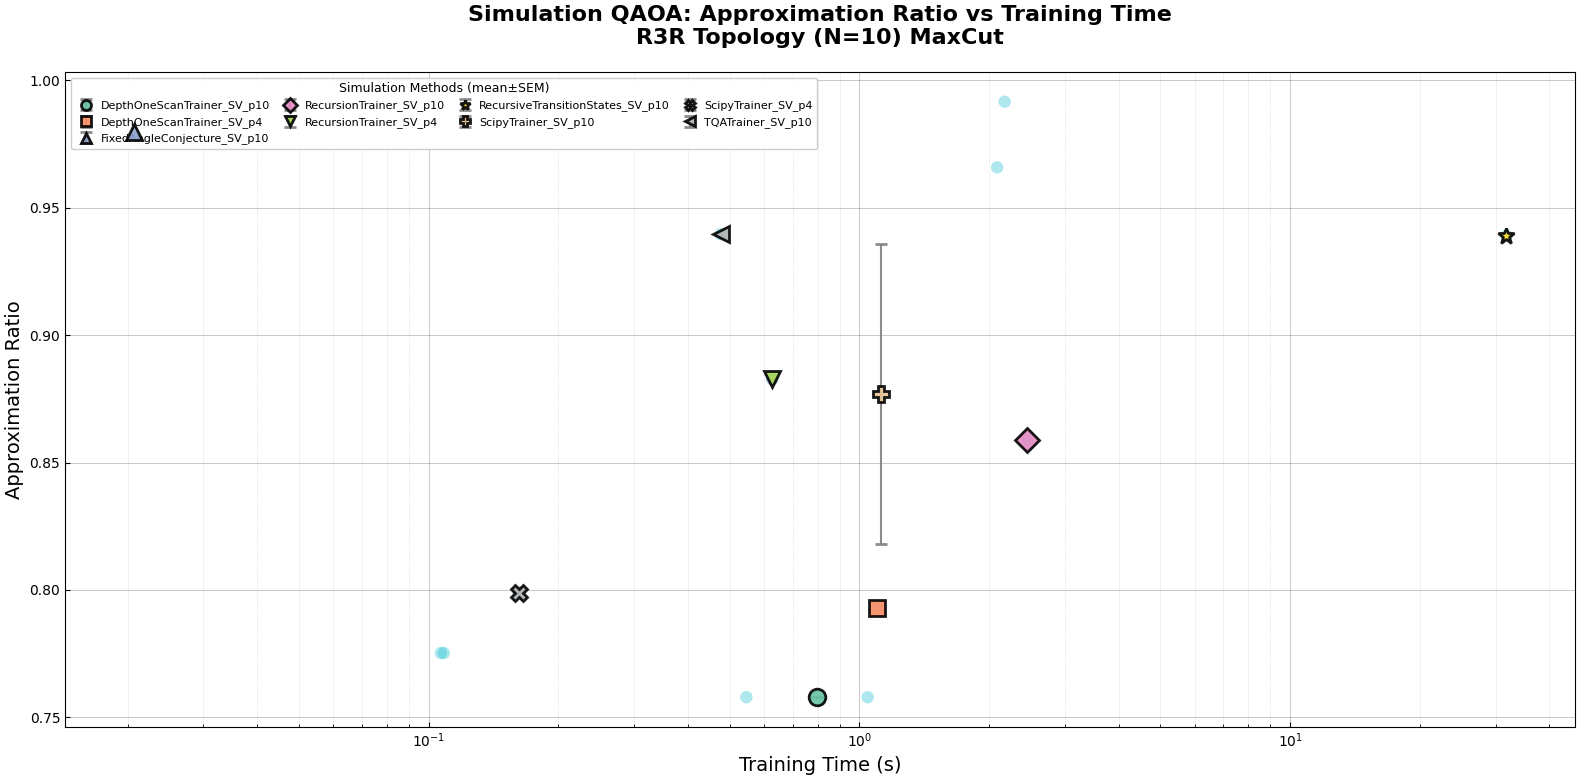


Summary Statistics
Total trials: 13
Unique instances: 2
Unique methods: ['DepthOneScanTrainer_SV', 'FixedAngleConjecture_SV', 'RecursionTrainer_SV', 'RecursiveTransitionStates_SV', 'ScipyTrainer_SV', 'TQATrainer_SV']
p values tested: [4, 10]


In [32]:
# === Simulation Method Analysis: Performance Ratio vs Training Time ===
print("=" * 80)
print(f"Simulation QAOA ({selected_topology}, N={selected_n}): Performance Ratio Analysis")
print("=" * 80)

if len(agg_df) > 0 and 'method' in agg_df.columns:
    # Check and report training time data availability
    total_trials = len(agg_df)
    valid_time_trials = (agg_df['MeanTime'].notna() & (agg_df['MeanTime'] > 0)).sum()
    zero_times = (agg_df['MeanTime'] == 0.0).sum()
    missing_times = agg_df['MeanTime'].isna().sum()
    
    print(f"\nTraining Time Data:")
    print(f"  Total trials: {total_trials}")
    print(f"  Valid training times: {valid_time_trials}/{total_trials} ({100*valid_time_trials/total_trials:.1f}%)")
    if zero_times > 0:
        print(f"  Zero training times: {zero_times}")
    if missing_times > 0:
        print(f"  NaN training times: {missing_times}")
    
    # Filter out rows with missing or zero training times
    agg_df_with_time = agg_df[(agg_df['MeanTime'].notna()) & (agg_df['MeanTime'] > 0)].copy()
    print(f"  Using {len(agg_df_with_time)} trials for time-based analysis\n")
    
    # Create combined method-p label for unique identification
    agg_df_with_time['method_p'] = agg_df_with_time['method'] + '_p' + agg_df_with_time['p'].astype(int).astype(str)
    
    # Calculate centroids and SEM for each method-p combination
    method_stats = agg_df_with_time.groupby(['method', 'p', 'method_p']).agg({
        'MeanTime': ['mean', 'std', 'count'],
        'Approximation_Ratio': ['mean', 'std', 'count']
    }).reset_index()
    method_stats.columns = ['method', 'p', 'method_p', 'mean_time', 'std_time', 'count_time', 
                           'mean_ratio', 'std_ratio', 'count_ratio']
    
    # Calculate standard error of the mean (SEM = std / sqrt(n))
    method_stats['sem_time'] = method_stats['std_time'] / np.sqrt(method_stats['count_time'])
    method_stats['sem_ratio'] = method_stats['std_ratio'] / np.sqrt(method_stats['count_ratio'])
    
    # Calculate statistics by depth for summary
    stats_by_depth = agg_df.groupby('p')['Approximation_Ratio'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('count', 'count'),
        ('min', 'min'),
        ('max', 'max')
    ]).reset_index()
    
    print("Statistics by p (depth):")
    print(stats_by_depth.to_string(index=False))
    
    # Create plot with all data points and method centroids with error bars
    fig, ax = plt.subplots(figsize=(16, 8))
    
    depths = sorted(agg_df_with_time['p'].unique())
    method_p_combos = sorted(method_stats['method_p'].unique())
    depth_colors = plt.cm.tab10(np.linspace(0, 1, len(depths)))
    
    # Marker styles for variety
    markers = ['o', 's', '^', 'D', 'v', '*', 'P', 'X', '<', '>', 'h', 'H']
    
    # First pass: Plot all individual data points (faded, colored by depth)
    for i, depth in enumerate(depths):
        depth_data = agg_df_with_time[agg_df_with_time['p'] == depth]
        n_points = len(depth_data)
        if n_points > 0:
            z_order = 1 if n_points > 20 else 2
            alpha = 0.15 if n_points > 20 else 0.35
            size = 60 if n_points > 20 else 80
            
            ax.scatter(
                depth_data['MeanTime'],
                depth_data['Approximation_Ratio'],
                alpha=alpha,
                s=size,
                color=depth_colors[i],
                marker='o',
                edgecolors='none',
                zorder=z_order
            )
    
    # Second pass: Plot method-p centroids with error bars (Set2 colors)
    method_p_colors = plt.cm.Set2(np.linspace(0, 1, len(method_p_combos)))
    for i, method_p in enumerate(method_p_combos):
        method_data = method_stats[method_stats['method_p'] == method_p]
        if len(method_data) > 0:
            ax.errorbar(
                method_data['mean_time'],
                method_data['mean_ratio'],
                yerr=method_data['sem_ratio'],
                fmt=markers[i % len(markers)],
                markersize=12,
                markerfacecolor=method_p_colors[i],
                markeredgecolor='black',
                markeredgewidth=2,
                ecolor='gray',
                elinewidth=1.5,
                capsize=4,
                capthick=1.5,
                alpha=0.9,
                label=method_p,
                zorder=10
            )
    
    ax.set_xlabel('Training Time (s)', fontsize=14)
    ax.set_ylabel('Approximation Ratio', fontsize=14)
    ax.set_title(f'Simulation QAOA: Approximation Ratio vs Training Time\n{selected_topology} Topology (N={selected_n}) MaxCut',
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xscale('log')
    
    ax.grid(True, linestyle='-', alpha=0.3, which='major')
    ax.grid(True, linestyle=':', alpha=0.2, which='minor')
    
    # Legend with 4 columns (hardware style)
    legend = ax.legend(fontsize=8, 
                       title='Simulation Methods (mean±SEM)', 
                       title_fontsize=9, 
                       loc='upper left', 
                       framealpha=0.95, 
                       ncol=4,
                       columnspacing=0.8, 
                       handletextpad=0.3,
                       markerscale=0.6)
    
    plt.tight_layout()
    plt.show()
    
    # Print method-p statistics summary
    print(f"\n{'='*80}")
    print("Summary Statistics")
    print("="*80)
    print(f"Total trials: {len(agg_df)}")
    print(f"Unique instances: {agg_df['instance'].nunique()}")
    print(f"Unique methods: {sorted(agg_df['method'].unique())}")
    print(f"p values tested: {sorted(agg_df['p'].unique())}")
    
else:
    print("No data available for method comparison")


Method Comparison at p = 10

Methods at p=10:
  Total trials: 10
  Unique methods: 6
  Methods: ['DepthOneScanTrainer_SV', 'FixedAngleConjecture_SV', 'RecursionTrainer_SV', 'RecursiveTransitionStates_SV', 'ScipyTrainer_SV', 'TQATrainer_SV']


Method Comparison at p = 10

Methods at p=10:
  Total trials: 10
  Unique methods: 6
  Methods: ['DepthOneScanTrainer_SV', 'FixedAngleConjecture_SV', 'RecursionTrainer_SV', 'RecursiveTransitionStates_SV', 'ScipyTrainer_SV', 'TQATrainer_SV']


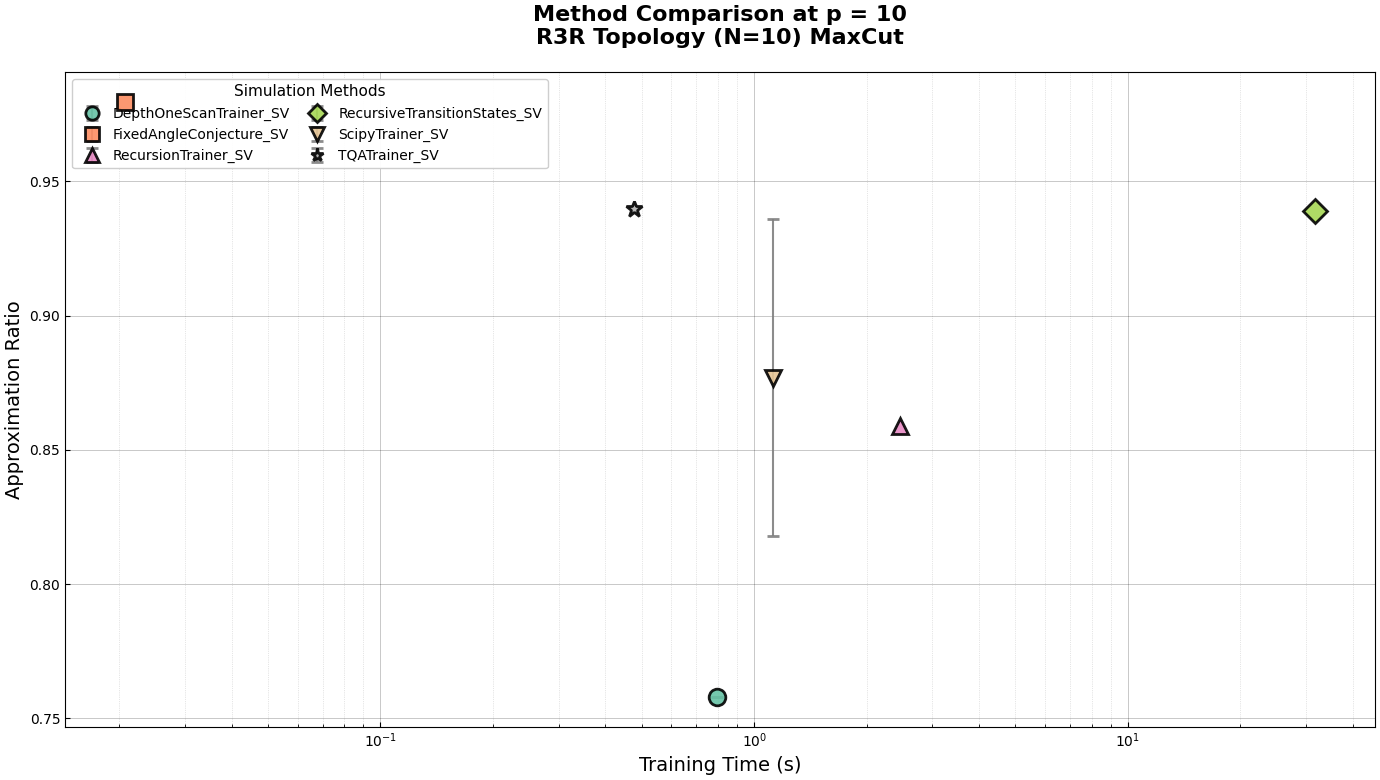


Method Rankings (by approximation ratio):
🥇 FixedAngleConjecture_SV
   Approximation Ratio: 0.9797 ± nan (SEM)
   Training Time:       0.0207 s
   Data points:         1
🥈 TQATrainer_SV
   Approximation Ratio: 0.9396 ± nan (SEM)
   Training Time:       0.4768 s
   Data points:         1
🥉 RecursiveTransitionStates_SV
   Approximation Ratio: 0.9389 ± nan (SEM)
   Training Time:       31.7716 s
   Data points:         1
4. ScipyTrainer_SV
   Approximation Ratio: 0.8770 ± 0.0590 (SEM)
   Training Time:       1.1197 s
   Data points:         4
5. RecursionTrainer_SV
   Approximation Ratio: 0.8589 ± nan (SEM)
   Training Time:       2.4547 s
   Data points:         1
6. DepthOneScanTrainer_SV
   Approximation Ratio: 0.7579 ± 0.0000 (SEM)
   Training Time:       0.7962 s
   Data points:         2


In [33]:
# === Selected-p Method Comparison ===
selected_p = sorted(agg_df_with_time['p'].unique())[-1] if len(agg_df_with_time) > 0 else 5  # Use highest p value

print("=" * 80)
print(f"Method Comparison at p = {selected_p}")
print("=" * 80)

if len(agg_df_with_time) > 0:
    # Filter to selected p value
    selected_p_data = agg_df_with_time[agg_df_with_time['p'] == selected_p].copy()
    
    if len(selected_p_data) > 0:
        # Calculate centroids for each method at this p value
        method_centroids = selected_p_data.groupby('method').agg({
            'MeanTime': ['mean', 'std', 'count'],
            'Approximation_Ratio': ['mean', 'std', 'count']
        }).reset_index()
        method_centroids.columns = ['method', 'mean_time', 'std_time', 'count_time',
                                    'mean_ratio', 'std_ratio', 'count_ratio']
        
        # Calculate SEM
        method_centroids['sem_time'] = method_centroids['std_time'] / np.sqrt(method_centroids['count_time'])
        method_centroids['sem_ratio'] = method_centroids['std_ratio'] / np.sqrt(method_centroids['count_ratio'])
        
        print(f"\nMethods at p={selected_p}:")
        print(f"  Total trials: {len(selected_p_data)}")
        print(f"  Unique methods: {len(method_centroids)}")
        print(f"  Methods: {sorted(method_centroids['method'].unique())}")
        
        # Create plot with method centroids only (hardware style)
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Use Set2 colors for methods (consistent with hardware notebook)
        n_methods = len(method_centroids)
        method_colors = plt.cm.Set2(np.linspace(0, 1, n_methods))
        markers = ['o', 's', '^', 'D', 'v', '*', 'P', 'X', '<', '>', 'h', 'H']
        
        for i, (idx, row) in enumerate(method_centroids.iterrows()):
            ax.errorbar(
                row['mean_time'],
                row['mean_ratio'],
                yerr=row['sem_ratio'],
                fmt=markers[i % len(markers)],
                markersize=12,
                markerfacecolor=method_colors[i],
                markeredgecolor='black',
                markeredgewidth=2.0,
                ecolor='gray',
                elinewidth=1.5,
                capsize=4,
                capthick=1.5,
                alpha=0.9,
                label=row['method'],
                zorder=10
            )
        
        ax.set_xlabel('Training Time (s)', fontsize=14)
        ax.set_ylabel('Approximation Ratio', fontsize=14)
        ax.set_title(f'Method Comparison at p = {selected_p}\n{selected_topology} Topology (N={selected_n}) MaxCut',
                    fontsize=16, fontweight='bold', pad=20)
        ax.set_xscale('log')
        
        ax.grid(True, linestyle='-', alpha=0.3, which='major')
        ax.grid(True, linestyle=':', alpha=0.2, which='minor')
        
        # Legend with 2 columns (hardware style)
        legend = ax.legend(fontsize=10, 
                           title='Simulation Methods', 
                           title_fontsize=11, 
                           loc='upper left', 
                           framealpha=0.95, 
                           ncol=2,
                           columnspacing=1.0, 
                           handletextpad=0.5,
                           markerscale=0.8)
        
        plt.tight_layout()
        plt.show()
        
        # Print rankings
        print(f"\n{'='*80}")
        print("Method Rankings (by approximation ratio):")
        print("="*80)
        rankings = method_centroids.sort_values('mean_ratio', ascending=False)[
            ['method', 'mean_time', 'mean_ratio', 'sem_ratio', 'count_ratio']
        ]
        for rank, (idx, row) in enumerate(rankings.iterrows(), 1):
            rank_emoji = "🥇" if rank == 1 else ("🥈" if rank == 2 else ("🥉" if rank == 3 else f"{rank}."))
            print(f"{rank_emoji} {row['method']}")
            print(f"   Approximation Ratio: {row['mean_ratio']:.4f} ± {row['sem_ratio']:.4f} (SEM)")
            print(f"   Training Time:       {row['mean_time']:.4f} s")
            print(f"   Data points:         {int(row['count_ratio'])}")
    else:
        print(f"No data available for p={selected_p}")
else:
    print("No data available for selected-p comparison")


## 6. Selected-p Method Comparison

Simplified comparison showing method-evaluator centroids at a chosen p-value. Focuses on method performance at specific circuit depth with:
- Method centroids only (no individual points)
- Error bars for both x and y axes (SEM)
- Compact 2-column legend
- Clear method differentiation with markers and colors

## 5. Method Comparison: Approximation Ratio vs Training Time

Comprehensive visualization showing all method-evaluator combinations with centroids and error bars. Follows hardware notebook's plotting style with:
- All individual datapoints (faded)
- Method-p centroids with SEM error bars
- Log-scale axes for better visualization
- 4-column legend for readability

## 4. Train/Test Split and Virtual Best Baseline

Split data into train (80%) and test (20%) sets based on instances. Compute Virtual Best baseline from test set: the oracle performance achieved by selecting the best method-evaluator combination at each resource level.

**Virtual Best = Test-set Oracle**:
- For each resource level (training time), select the method with best approximation ratio
- Provides upper bound on achievable performance
- Used as reference baseline in comparison plots


=== QAOA Stochastic Benchmark Analysis Summary ===


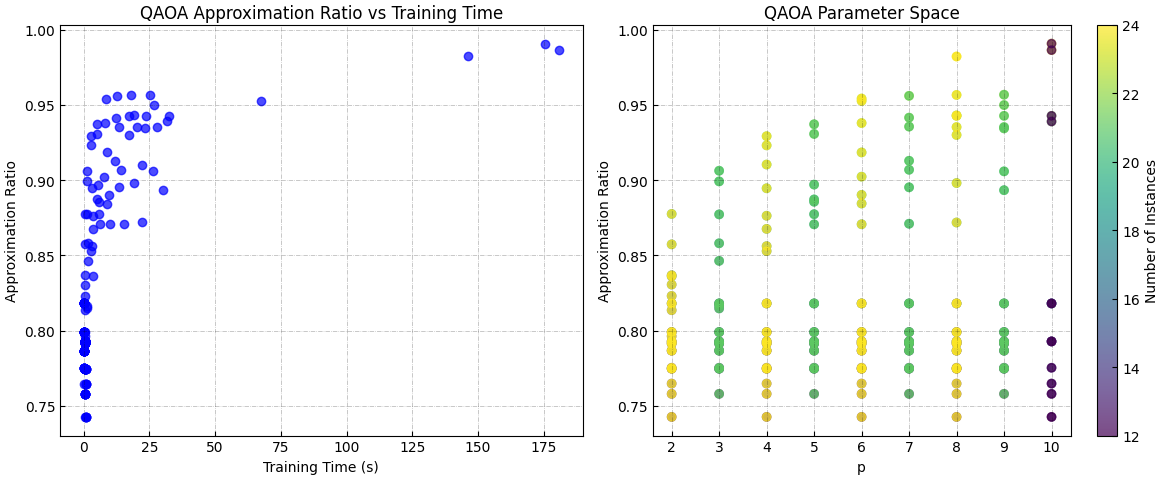


Original Data Summary:
Processed 192 QAOA data rows
Circuit depths (p): [2, 3, 4, 5, 6, 7, 8, 9, 10]
Approximation Ratio range: [0.7426, 0.9907]
Training time range: [0.0993, 180.6608] seconds

=== Analysis Components Status ===
Bootstrap: COMPLETED (0 results)
Interpolation: COMPLETED (0 results)
Statistics: FAILED
Baseline: SKIPPED (single instance, limited baseline value)

=== Overall Status ===
Completed components: Bootstrap, Interpolation
Skipped components: Baseline (appropriate for single instance)
Failed components: Statistics
Analysis completion rate: 67% (2/3 applicable components)

Completed analysis components: 2


In [13]:
# === Final Analysis Summary and Status Report ===
print("\n=== QAOA Stochastic Benchmark Analysis Summary ===")

# Original data visualization
if 'agg_df' in locals() and agg_df is not None and not agg_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # PerfRatio vs training time
    valid_data = agg_df[agg_df['Approximation_Ratio'] != -999]
    if len(valid_data) > 0:
        ax1.scatter(valid_data['MeanTime'], valid_data['Approximation_Ratio'], alpha=0.7, color='blue')
        ax1.set_xlabel('Training Time (s)')
        ax1.set_ylabel('Approximation Ratio')
        ax1.set_title('QAOA Approximation Ratio vs Training Time')
        ax1.grid(True, alpha=0.3)
    
    # Parameter space visualization
    if 'p' in agg_df.columns and 'Approximation_Ratio' in agg_df.columns and len(valid_data) > 0:
        scatter = ax2.scatter(valid_data['p'], valid_data['Approximation_Ratio'],
                             c=valid_data['Approximation_Ratio'], alpha=0.7)
        ax2.set_xlabel('p')
        ax2.set_ylabel('Approximation Ratio')
        ax2.set_title('QAOA Parameter Space')
        ax2.grid(True, alpha=0.3)
        # Plot number of instances on colorbar for each depth
        num_instances = valid_data['p'].value_counts()
        scatter = ax2.scatter(valid_data['p'], valid_data['Approximation_Ratio'],
                             c=num_instances[valid_data['p']].values, alpha=0.7)
        plt.colorbar(scatter, ax=ax2, label='Number of Instances')
    plt.tight_layout()
    plt.show()
    
    # Data summary
    print(f"\nOriginal Data Summary:")
    print(f"Processed {len(agg_df)} QAOA data rows")
    if len(valid_data) > 0:
        # Check if gamma and beta columns exist
        if 'gamma' in valid_data.columns and 'beta' in valid_data.columns:
            print(f"Parameter space: Gamma [{valid_data['gamma'].min():.3f}, {valid_data['gamma'].max():.3f}], "
                  f"Beta [{valid_data['beta'].min():.3f}, {valid_data['beta'].max():.3f}]")
        print(f"Circuit depths (p): {sorted(valid_data['p'].unique())}")
        print(f"Approximation Ratio range: [{valid_data['Approximation_Ratio'].min():.4f}, {valid_data['Approximation_Ratio'].max():.4f}]")
        print(f"Training time range: [{valid_data['MeanTime'].min():.4f}, {valid_data['MeanTime'].max():.4f}] seconds")

# === Analysis Components Status ===
print(f"\n=== Analysis Components Status ===")
completed_components = []
skipped_components = []
failed_components = []

# Bootstrap
if hasattr(sb, 'bs_results') and sb.bs_results is not None:
    completed_components.append('Bootstrap')
    print(f"Bootstrap: COMPLETED ({sb.bs_results.shape[0]} results)")
else:
    failed_components.append('Bootstrap')
    print("Bootstrap: FAILED")

# Interpolation
if hasattr(sb, 'interp_results') and sb.interp_results is not None:
    completed_components.append('Interpolation')
    print(f"Interpolation: COMPLETED ({sb.interp_results.shape[0]} results)")
else:
    failed_components.append('Interpolation')
    print("Interpolation: FAILED")

# Statistics
if hasattr(sb, 'stat_results'):
    if sb.stat_results is not None:
        completed_components.append('Statistics')
        print(f"Statistics: COMPLETED ({sb.stat_results.shape[0]} results)")
    else:
        skipped_components.append('Statistics')
        print("Statistics: SKIPPED (single instance or insufficient data)")
else:
    failed_components.append('Statistics')
    print("Statistics: FAILED")

# Baseline
if hasattr(sb, 'baseline') and sb.baseline is not None:
    completed_components.append('Baseline')
    print("Baseline: COMPLETED")
else:
    # Check if baseline was skipped for single instance
    if (hasattr(sb, 'interp_results') and sb.interp_results is not None and len(sb.interp_results) <= 5):
        skipped_components.append('Baseline')
        print("Baseline: SKIPPED (single instance, limited baseline value)")
    else:
        failed_components.append('Baseline')
        print("Baseline: FAILED")

# Overall status
print(f"\n=== Overall Status ===")
total_components = 4
actual_completed = len(completed_components)
actual_attempted = total_components - len(skipped_components)

print(f"Completed components: {', '.join(completed_components) if completed_components else 'None'}")
if skipped_components:
    print(f"Skipped components: {', '.join(skipped_components)} (appropriate for single instance)")
if failed_components:
    print(f"Failed components: {', '.join(failed_components)}")

# Adjusted completion rate
if actual_attempted > 0:
    completion_rate = actual_completed / actual_attempted * 100
    print(f"Analysis completion rate: {completion_rate:.0f}% ({actual_completed}/{actual_attempted} applicable components)")
else:
    print("No applicable components for analysis")

# Results summary
if completed_components:
    print(f"\nCompleted analysis components: {len(completed_components)}")
else:
    print("\nNo analysis components completed successfully")